In [1]:
import numpy as np
import matplotlib.pyplot as plt
import OptimalBattery.util as ut
from Functional_Fusion.dataset import DataSetMDTB
import os
import pickle
import Functional_Fusion.atlas_map as am
from IndividualParcellation.global_config import *
import OptimalBattery.evaluate as ev
import PcmPy as pcm
import seaborn as sns
import nilearn.plotting as plotting
import nitools as nt
import pandas as pd


Default device set to: cuda


# define atlas for data used and ROI mask dir

In [2]:
space = 'SUIT3'
atlas,_= am.get_atlas(atlas_str=space)
base_dir = 'Y:/data/FunctionalFusion/'
if not os.path.exists(base_dir):
    base_dir = '/cifs/diedrichsen/data/FunctionalFusion/'
cort_dir = 'Y:/data/Atlas_templates/fs_LR_32'

# Get Vs for mdtb_1 and mdtb_2 from nettekoven 32

In [3]:
model_dir = 'Y:/data/Cerebellum/ProbabilisticParcellationModel/Models/Models_03/'
model_name='NettekovenSym32_space-MNISymC2_D5.pickle'
with open(model_dir+model_name, 'rb') as f:
    full_model = pickle.load(f)[0]

# load emission model & Vs for mdtb ses-1
mdtb_1_emission = full_model.emissions[0]
mdtb_1_Vs = mdtb_1_emission.V
VL_mdtb_1 = mdtb_1_Vs.cpu().numpy()
VL_mdtb_1 = VL_mdtb_1[:28,:]

mdtb_2_emission = full_model.emissions[1]
mdtb_2_Vs = mdtb_2_emission.V
VL_mdtb_2 = mdtb_2_Vs.cpu().numpy()


In [4]:
lut_file_dir = 'Y:/data/Cerebellum/ProbabilisticParcellationModel/Atlases/NettekovenSym32.lut'
lut = pd.read_csv(lut_file_dir, sep=' ', header=None)
# ge the parcel names from the 4th column
parcel_names = lut.iloc[:,4].values
parcel_names = parcel_names[1:]
len(parcel_names)

32

# Load data

In [5]:
MDTB_dataset = DataSetMDTB('/cifs/diedrichsen/data/FunctionalFusion/MDTB')
if not os.path.exists('/cifs/diedrichsen/data/FunctionalFusion/MDTB'):
    MDTB_dataset = DataSetMDTB('Y:/data/FunctionalFusion/MDTB')

data_mdtb_s1_run,info_mdtb_1_run  =MDTB_dataset.get_data(space=space,ses_id='ses-s1',type='CondRun')
data_mdtb_s1_run[np.isnan(data_mdtb_s1_run)] = 0
data_mdtb_s1_run = data_mdtb_s1_run[:,:,:]



data_mdtb_s1_all,info_mdtb_1_all  =MDTB_dataset.get_data(space=space,ses_id='ses-s1',type='CondAll')
data_mdtb_s1_all[np.isnan(data_mdtb_s1_all)] = 0
data_mdtb_s1_all = data_mdtb_s1_all[:,:,:]




data_mdtb_s2_all,info_mdtb_2_all  =MDTB_dataset.get_data(space=space,ses_id='ses-s2',type='CondAll')
data_mdtb_s2_all[np.isnan(data_mdtb_s2_all)] = 0


In [6]:
data_mdtb_s1_run,info_mdtb_1_run = ut.recenter_fmri_data(data_mdtb_s1_run,info_mdtb_1_run,task_column_name='cond_name',center_condition='rest')
print(data_mdtb_s1_run.shape)

data_mdtb_s1_all,info_mdtb_1_all = ut.recenter_fmri_data(data_mdtb_s1_all,info_mdtb_1_all,task_column_name='cond_name',center_condition='rest')
print(data_mdtb_s1_all.shape)


(24, 448, 6918)
(24, 28, 6918)


In [7]:
# make a data of shape 1 x data_mdtb_s1_all.shape[2] of 1s
ROI_mask = np.ones((data_mdtb_s1_all.shape[2]),)
ROI_indices = np.where(ROI_mask == 1)[0]



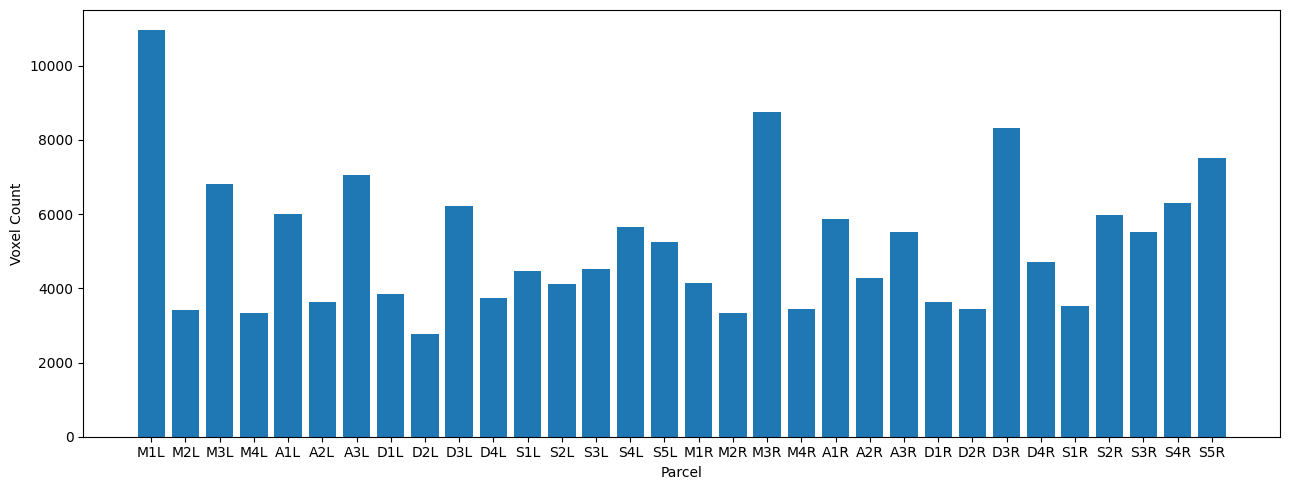

In [8]:
# get top 4 parcels with highest voxel counts within ROI
total_parcel_counts = np.zeros(32)

for subject_data in data_mdtb_s1_all:
    data = subject_data[:, ROI_indices]
    
    data_projected = VL_mdtb_1.T @ data
    data_projected_onehot = ev.get_U_hat_one_hot(data_projected)[0]
    
    total_parcel_counts += np.sum(data_projected_onehot, axis=1)

plt.figure(figsize=(13, 5))
plt.bar(range(1, 33), total_parcel_counts, tick_label=parcel_names)
plt.xlabel('Parcel')
plt.ylabel('Voxel Count')
plt.tight_layout()
plt.show()

# choose 8 parcels with top voxel counts
top_parcels = np.argsort(total_parcel_counts)[::-1][:8]


In [9]:
VLib = VL_mdtb_1[:,top_parcels]
vtest = VL_mdtb_2[:,top_parcels]

# Get crossvalidated second moment matrix (GLib)

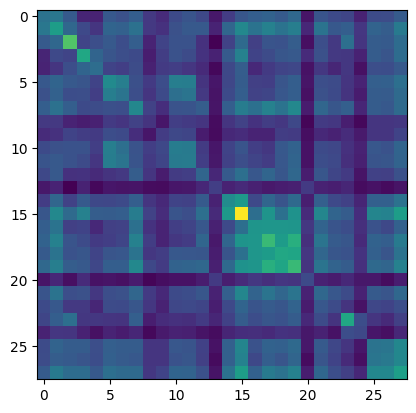

In [10]:
cond_vec = np.tile(np.arange(1, 28 + 1), 16)
part_vec = np.repeat(np.arange(1, 16 + 1), 28)
Gs_list = []
E_list = []
for i in range(data_mdtb_s1_run.shape[0]):
    Gs,E = pcm.util.est_G_crossval(data_mdtb_s1_run[i][:,ROI_indices] , cond_vec, part_vec)
    Gs_list.append(Gs)
    E_list.append(E)

Gs_list = np.stack(Gs_list, 0)
G_Lib = np.mean(Gs_list, axis=0)

plt.imshow(G_Lib)

In [11]:
D = ut.build_combinations(G_Lib, strategy='random',n_iter=100,n_tasks=6,seed=3,replacement=True)
D = D.reset_index(drop=True)
D_ev = ev.real_evaluate_dataframe_multiregion(D, data_mdtb_s1_all,VLib,data_mdtb_s2_all, vtest,ROI_indices)



Processing combination: 0
Processing combination: 10
Processing combination: 20
Processing combination: 30
Processing combination: 40
Processing combination: 50
Processing combination: 60
Processing combination: 70
Processing combination: 80
Processing combination: 90


In [13]:
%prun D_ev = ev.real_evaluate_dataframe_multiregion(D, data_mdtb_s1_all, VLib, data_mdtb_s2_all, vtest, ROI_indices)


Processing combination: 0
Processing combination: 10
Processing combination: 20
Processing combination: 30
Processing combination: 40
Processing combination: 50
Processing combination: 60
Processing combination: 70
Processing combination: 80
Processing combination: 90
 

         82535 function calls (79304 primitive calls) in 6.244 seconds

   Ordered by: internal time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
      100    1.066    0.011    1.066    0.011 {method 'argmax' of 'numpy.ndarray' objects}
      200    0.813    0.004    1.418    0.007 evaluate.py:23(normalize_matrix)
      100    0.554    0.006    5.986    0.060 evaluate.py:227(real_evaluate_combination_multiregion)
      404    0.493    0.001    0.493    0.001 {built-in method numpy.array}
      100    0.485    0.005    0.485    0.005 estimate.py:25(estimate_Us_projection)
 2022/812    0.455    0.000    2.646    0.003 {built-in method numpy.core._multiarray_umath.implement_array_function}
  204/102    0.400    0.002    0.400    0.004 {built-in method pt.tensor}
      800    0.368    0.000    0.368    0.000 {method 'reduce' of 'numpy.ufunc' objects}
  400/200    0.327    0.001    0.327    0.002 {method 'item' of 'pt._C.TensorBase' objects}
      200    0.302   

(0.5, 1.0)

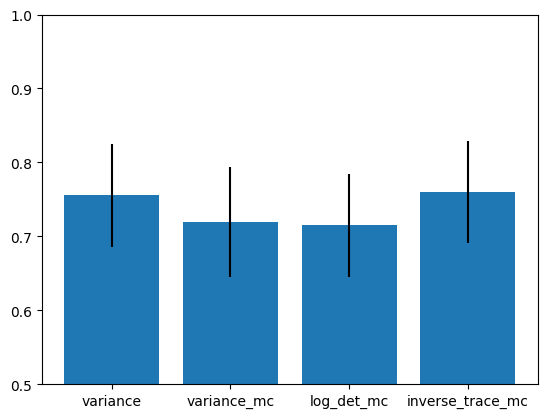

In [19]:
metrics = ['variance','variance_mc','log_det_mc','inverse_trace_mc']
best_eval_value = []
best_eval_std = []
for metric in metrics:
    best_battery = D_ev.loc[D_ev[metric].idxmax()]  # Get the battery with the highest value of the metric
    best_eval_value.append(best_battery['cos'])
    best_eval_std.append(best_battery['cos_std']) 

# plot with error bars
plt.bar(metrics, best_eval_value, yerr=best_eval_std)
plt.ylim(0.5, 1)

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Assuming D_ev is already loaded as a DataFrame
n_bootstrap = 20000
boot_best_log_det_mc_cos = []
boot_best_variance_cos = []

for _ in range(n_bootstrap):
    if _ % 1000 == 0:
        print(f'Bootstrap iteration {_}')
    sample = D_ev.sample(n=len(D_ev), replace=True)
    # Best battery based on log_det_mc
    log_det_mc_idx = sample['log_det_mc'].idxmax()
    best_log_det_mc_cos = sample.loc[log_det_mc_idx, 'cos']
    best_log_det_mc_cos = best_log_det_mc_cos.iloc[0] if isinstance(best_log_det_mc_cos, pd.Series) else best_log_det_mc_cos
    boot_best_log_det_mc_cos.append(best_log_det_mc_cos)

    # Best battery based on variance
    variance_idx = sample['variance'].idxmax()
    best_variance_cos = sample.loc[variance_idx, 'cos']
    best_variance_cos = best_variance_cos.iloc[0] if isinstance(best_variance_cos, pd.Series) else best_variance_cos
    boot_best_variance_cos.append(best_variance_cos)





Bootstrap iteration 0
Bootstrap iteration 1000
Bootstrap iteration 2000
Bootstrap iteration 3000
Bootstrap iteration 4000
Bootstrap iteration 5000
Bootstrap iteration 6000
Bootstrap iteration 7000
Bootstrap iteration 8000
Bootstrap iteration 9000
Bootstrap iteration 10000
Bootstrap iteration 11000
Bootstrap iteration 12000
Bootstrap iteration 13000
Bootstrap iteration 14000
Bootstrap iteration 15000
Bootstrap iteration 16000
Bootstrap iteration 17000
Bootstrap iteration 18000
Bootstrap iteration 19000


(array([1.2845e+04, 1.9280e+03, 0.0000e+00, 8.0000e+00, 5.2150e+03,
        2.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 2.0000e+00]),
 array([0.73177975, 0.73631372, 0.74084769, 0.74538167, 0.74991564,
        0.75444961, 0.75898358, 0.76351755, 0.76805152, 0.77258549,
        0.77711946]),
 <BarContainer object of 10 artists>)

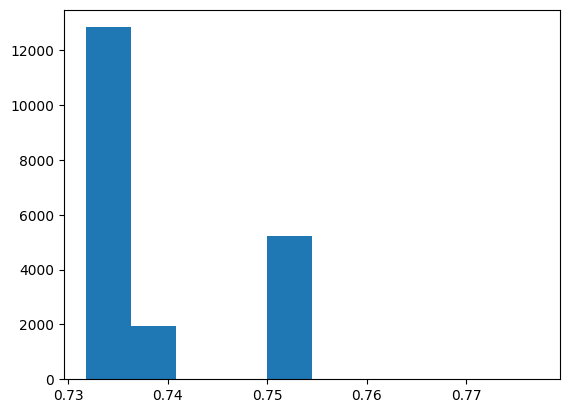

In [ ]:
plt.hist(boot_best_log_det_mc_cos, bins=10)


(array([7.5000e+01, 8.3000e+02, 1.0000e+00, 4.5950e+03, 0.0000e+00,
        0.0000e+00, 1.6770e+03, 1.2795e+04, 0.0000e+00, 2.7000e+01]),
 array([0.72771758, 0.73564194, 0.74356631, 0.75149068, 0.75941504,
        0.76733941, 0.77526377, 0.78318814, 0.79111251, 0.79903687,
        0.80696124]),
 <BarContainer object of 10 artists>)

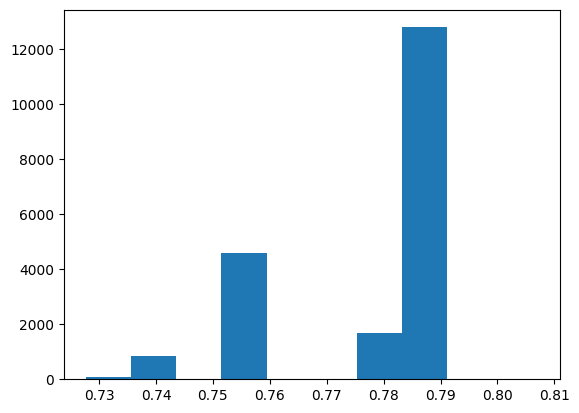

In [ ]:
plt.hist(boot_best_variance_cos, bins=10)


# check task batteries with different sizes

In [24]:
battery_sizes = [3,4,5,6,7,8,10,12,14,16,18,20,22,24]
battery_sizes = [3,4,5,6,7,8,8,10,14,18]

In [25]:
results_list = []
metrics = ["variance", "variance_mc", "log_det_mc"]

for i in battery_sizes:
    print(f"Processing battery size: {i}")
    
    # Generate task combinations and evaluate
    D = ut.build_combinations(G_Lib, strategy='random',n_iter=10000,n_tasks=i,seed=1,replacement=False)
    D = D.reset_index(drop=True)
    D_ev = ev.real_evaluate_dataframe_multiregion(D, data_mdtb_s1_all,VLib,data_mdtb_s2_all, vtest,ROI_indices)
    
    
    for metric in metrics:
        max_idx = D_ev[metric].idxmax()
        cos = D_ev.loc[max_idx, "cos"]
        cos_std = D_ev.loc[max_idx, "cos_std"]
        
        results_list.append({
            "battery_size": i,
            "metric": metric,
            "cos": cos,
            "cos_std": cos_std
        })
    
results_df = pd.DataFrame(results_list)



Processing battery size: 3
Processing combination: 0
Processing combination: 10
Processing combination: 20
Processing combination: 30
Processing combination: 40
Processing combination: 50
Processing combination: 60
Processing combination: 70
Processing combination: 80
Processing combination: 90
Processing combination: 100
Processing combination: 110
Processing combination: 120
Processing combination: 130
Processing combination: 140
Processing combination: 150
Processing combination: 160
Processing combination: 170
Processing combination: 180
Processing combination: 190
Processing combination: 200
Processing combination: 210
Processing combination: 220
Processing combination: 230
Processing combination: 240
Processing combination: 250
Processing combination: 260
Processing combination: 270
Processing combination: 280
Processing combination: 290
Processing combination: 300
Processing combination: 310
Processing combination: 320
Processing combination: 330
Processing combination: 340
Proc

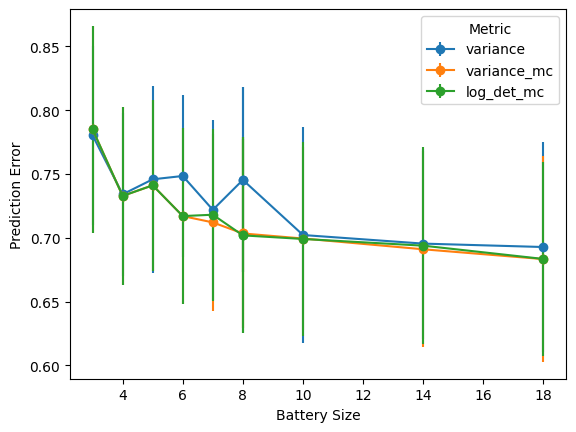

In [26]:
for metric in metrics:
    subset = results_df[results_df["metric"] == metric] 
    
    # Plot line with error bars
    plt.errorbar(subset["battery_size"], subset["cos"], yerr=subset["cos_std"], 
                 fmt='-o', label=metric)
    
plt.xlabel("Battery Size")
plt.ylabel("Prediction Error")
plt.legend(title="Metric")
plt.show()

# n parcels

In [16]:
n_parcel = [2,3,4,5,6,7,8,10,12]


In [ ]:
results_list = []
total_parcel_counts = np.zeros(32)
for subject_data in data_mdtb_s1_all:
        data = subject_data[:, ROI_indices]
        
        data_projected = VL_mdtb_1.T @ data
        data_projected_onehot = ev.get_U_hat_one_hot(data_projected)[0]
        
        total_parcel_counts += np.sum(data_projected_onehot, axis=1)


for i in n_parcel:
    print(f"Processing n_parcel: {i}")
    
    # choose top n parcels with highest voxel counts
    top_parcels = np.argsort(total_parcel_counts)[::-1][:i]
    VLib = VL_mdtb_1[:,top_parcels]
    vtest =  VL_mdtb_2[:,top_parcels]
    D = ut.build_combinations(G_Lib, strategy='random',n_iter=10,n_tasks=8,seed=1,replacement=True)
    D = D.reset_index(drop=True)
    D_ev = ev.real_evaluate_dataframe_multiregion(D, data_mdtb_s1_all,VLib,data_mdtb_s2_all, vtest,ROI_indices)
    

    for metric in metrics:
        max_idx = D_ev[metric].idxmax()
        cos = D_ev.loc[max_idx, "cos"]
        cos_std = D_ev.loc[max_idx, "cos_std"]
        
        results_list.append({
            "n_parcel": i,
            "metric": metric,
            "cos": cos,
            "cos_std": cos_std
        })

results_df_parcel = pd.DataFrame(results_list)




Processing n_parcel: 2
Processing combination: 0
Processing n_parcel: 3
Processing combination: 0


KeyboardInterrupt: 

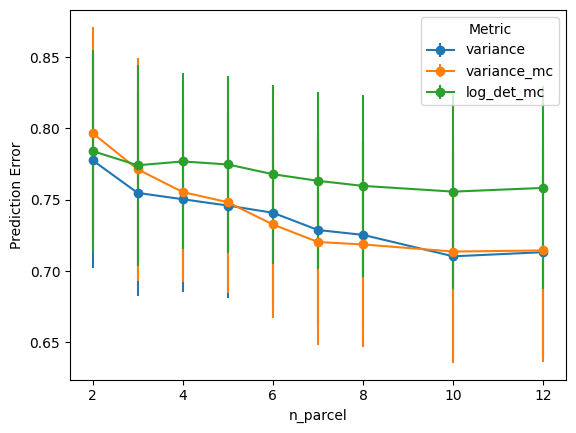

In [28]:
for metric in metrics:
    subset = results_df_parcel[results_df_parcel["metric"] == metric] 
    
    # Plot line with error bars
    plt.errorbar(subset["n_parcel"], subset["cos"], yerr=subset["cos_std"], 
                 fmt='-o', label=metric)
    
plt.xlabel("n_parcel")
plt.ylabel("Prediction Error")
plt.legend(title="Metric")
plt.show()